# Following the Federal AI Dollar

This project explores federal AI contracts to understand how spending has changed, which agencies drive it, who receives the money, and what the government is buying.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load and Inspect the Data

Load the USAspending data and review its structure.

In [2]:
contracts = pd.read_csv(
    "../data/raw/Contracts_PrimeTransactions_2026-09-07_H23M48S59_1.csv",
    low_memory=False
)

print("Contracts loaded successfully")
print("Rows and columns:")
print(contracts.shape)

Contracts loaded successfully
Rows and columns:
(2732, 297)


In [3]:
print("First 5 rows:")
print(contracts.head())

First 5 rows:
                     contract_transaction_unique_key  \
0  7528_7528_75Q80119F32007_P00001_HHSA2902016000...   
1  7528_7528_75Q80119F32007_P00002_HHSA2902016000...   
2  7528_7528_75Q80119F32007_P00003_HHSA2902016000...   
3     7528_7528_75Q80121F32010_0_HHSA290201600003I_0   
4  7528_7528_75Q80121F32010_P00001_HHSA2902016000...   

                           contract_award_unique_key   award_id_piid  \
0  CONT_AWD_75Q80119F32007_7528_HHSA290201600003I...  75Q80119F32007   
1  CONT_AWD_75Q80119F32007_7528_HHSA290201600003I...  75Q80119F32007   
2  CONT_AWD_75Q80119F32007_7528_HHSA290201600003I...  75Q80119F32007   
3  CONT_AWD_75Q80121F32010_7528_HHSA290201600003I...  75Q80121F32010   
4  CONT_AWD_75Q80121F32010_7528_HHSA290201600003I...  75Q80121F32010   

  modification_number  transaction_number  parent_award_agency_id  \
0              P00001                 0.0                  7528.0   
1              P00002                 0.0                  7528.0   
2        

In [4]:
print("Column names:")

for column in contracts.columns:
    print(column)

Column names:
contract_transaction_unique_key
contract_award_unique_key
award_id_piid
modification_number
transaction_number
parent_award_agency_id
parent_award_agency_name
parent_award_id_piid
parent_award_modification_number
federal_action_obligation
total_dollars_obligated
total_outlayed_amount_for_overall_award
base_and_exercised_options_value
current_total_value_of_award
base_and_all_options_value
potential_total_value_of_award
disaster_emergency_fund_codes_for_overall_award
outlayed_amount_from_COVID-19_supplementals_for_overall_award
obligated_amount_from_COVID-19_supplementals_for_overall_award
outlayed_amount_from_IIJA_supplemental_for_overall_award
obligated_amount_from_IIJA_supplemental_for_overall_award
action_date
action_date_fiscal_year
period_of_performance_start_date
period_of_performance_current_end_date
period_of_performance_potential_end_date
ordering_period_end_date
solicitation_date
awarding_agency_code
awarding_agency_name
awarding_sub_agency_code
awarding_sub_age

## 2. Data Cleaning

Select relevant fields and identify explicit AI contract transactions.

In [5]:
ai_contracts = contracts[
    [
        "award_id_piid",
        "action_date",
        "action_date_fiscal_year",
        "federal_action_obligation",
        "awarding_agency_name",
        "awarding_sub_agency_name",
        "recipient_name",
        "transaction_description",
        "product_or_service_code_description",
        "naics_description"
    ]
].copy()

print("New dataset shape:")
print(ai_contracts.shape)

print("\nFirst 5 rows:")
print(ai_contracts.head())

New dataset shape:
(2732, 10)

First 5 rows:
    award_id_piid action_date  action_date_fiscal_year  \
0  75Q80119F32007  2020-01-21                     2020   
1  75Q80119F32007  2020-02-20                     2020   
2  75Q80119F32007  2021-11-10                     2022   
3  75Q80121F32010  2020-10-13                     2021   
4  75Q80121F32010  2022-02-15                     2022   

   federal_action_obligation                     awarding_agency_name  \
0                       0.00  Department of Health and Human Services   
1                  788740.00  Department of Health and Human Services   
2                     -99.58  Department of Health and Human Services   
3                 1008646.00  Department of Health and Human Services   
4                     -72.11  Department of Health and Human Services   

                     awarding_sub_agency_name               recipient_name  \
0  Agency for Healthcare Research and Quality  INSIGNIA FEDERAL GROUP, LLC   
1  Agency f

In [6]:
ai_match = ai_contracts[
    "transaction_description"
].str.contains(
    "artificial intelligence",
    case=False,
    na=False
)

print("Total transactions:")
print(len(ai_contracts))

print("\nTransactions containing 'artificial intelligence':")
print(ai_match.sum())

print("\nTransactions NOT containing 'artificial intelligence':")
print((~ai_match).sum())

Total transactions:
2732

Transactions containing 'artificial intelligence':
2705

Transactions NOT containing 'artificial intelligence':
27


In [7]:
not_ai_match = ai_contracts[~ai_match]

print("Transactions without the exact phrase 'artificial intelligence':")
print(
    not_ai_match[
        [
            "action_date",
            "recipient_name",
            "transaction_description"
        ]
    ].to_string(index=False)
)

Transactions without the exact phrase 'artificial intelligence':
action_date                          recipient_name                                                                                                                                                                        transaction_description
 2019-11-12                      UTECH PRODUCTS INC                                                                                                                                        IMAGEARK FOR ARTIFICIAL-INTELLIGENCE ENHANCED ENDOSCOPY
 2019-11-14                      UTECH PRODUCTS INC                                                                                                  IMAGEARK FOR ARTIFICIAL-INTELLIGENCE ENHANCED ENDOSCOPY CHANGE PO FROM 523A08014 TO 523D00002
 2024-01-23 DELTA BRAVO ARTIFICIAL INTELLIGENCE INC                                                                                                                                 NSF CONVERGENCE ACCELERATO

In [8]:
ai_match_clean = ai_contracts[
    "transaction_description"
].str.contains(
    r"artificial[\s-]+intelligence",
    case=False,
    na=False,
    regex=True
)

print("Total transactions:")
print(len(ai_contracts))

print("\nTransactions matching our improved AI rule:")
print(ai_match_clean.sum())

print("\nTransactions not matching our improved AI rule:")
print((~ai_match_clean).sum())

Total transactions:
2732

Transactions matching our improved AI rule:
2726

Transactions not matching our improved AI rule:
6


In [9]:
unmatched = ai_contracts[~ai_match_clean]

print("Remaining unmatched transactions:")
print(
    unmatched[
        [
            "action_date",
            "recipient_name",
            "transaction_description"
        ]
    ].to_string(index=False)
)

Remaining unmatched transactions:
action_date                          recipient_name                                                            transaction_description
 2024-01-23 DELTA BRAVO ARTIFICIAL INTELLIGENCE INC                     NSF CONVERGENCE ACCELERATOR TRACK K: EQUITABLE WATER SOLUTIONS
 2025-06-06 DELTA BRAVO ARTIFICIAL INTELLIGENCE INC                                       CONVERGENCE ACCELERATOR FUTURE WATER SYSTEMS
 2020-06-30 ARTIFICIAL INTELLIGENCE ENGINEERING LLC                       SOLARWINDS ARM4000 1YR FOR THE NYARNG REQUIRED IN LATHAM, NY
 2024-03-08              KREATIVE TECHNOLOGIES, LLC ENTERPRISE INFORMATION MANAGEMENT, PATIENT MISMATCH ARTIFICIAL & INTELLIGENCE TOOL
 2026-01-23 DELTA BRAVO ARTIFICIAL INTELLIGENCE INC                                       CONVERGENCE ACCELERATOR FUTURE WATER SYSTEMS
 2026-06-04 DELTA BRAVO ARTIFICIAL INTELLIGENCE INC                    CONVERGENCE ACCELERATOR FUTURE WATER SYSTEMS EXERCISE OPTION #1


## 4. Feature Engineering

Group contracts into DoD and other federal agencies.

In [10]:
ai_clean = ai_contracts[ai_match_clean].copy()

print("Original transactions:")
print(len(ai_contracts))

print("\nClean AI transactions:")
print(len(ai_clean))

print("\nTransactions removed:")
print(len(ai_contracts) - len(ai_clean))

Original transactions:
2732

Clean AI transactions:
2726

Transactions removed:
6


## 3. Exploratory Analysis

Explore spending trends, agencies, and recipients.

In [11]:
spending_by_year = (
    ai_clean
    .groupby("action_date_fiscal_year")["federal_action_obligation"]
    .sum()
)

print("AI contract obligations by fiscal year:")
print(spending_by_year)

AI contract obligations by fiscal year:
action_date_fiscal_year
2020    1.623354e+08
2021    1.870728e+08
2022    1.771434e+08
2023    2.092828e+08
2024    2.734547e+08
2025    3.843387e+08
2026    3.246589e+08
Name: federal_action_obligation, dtype: float64


In [12]:
spending_millions = spending_by_year / 1_000_000

print("AI contract obligations by fiscal year, in millions:")
print(spending_millions.round(1))

AI contract obligations by fiscal year, in millions:
action_date_fiscal_year
2020    162.3
2021    187.1
2022    177.1
2023    209.3
2024    273.5
2025    384.3
2026    324.7
Name: federal_action_obligation, dtype: float64


In [13]:
print("Earliest transaction date:")
print(ai_clean["action_date"].min())

print("\nLatest transaction date:")
print(ai_clean["action_date"].max())

Earliest transaction date:
2019-10-03

Latest transaction date:
2026-09-04


In [14]:
transactions_by_year = (
    ai_clean
    .groupby("action_date_fiscal_year")
    .size()
)

print("AI contract transactions by fiscal year:")
print(transactions_by_year)

AI contract transactions by fiscal year:
action_date_fiscal_year
2020    185
2021    232
2022    387
2023    352
2024    491
2025    626
2026    453
dtype: int64


In [15]:
top_recipients = (
    ai_clean
    .groupby("recipient_name")["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 recipients by AI contract obligations:")
print((top_recipients / 1_000_000).round(1))

Top 10 recipients by AI contract obligations:
recipient_name
ECS FEDERAL, LLC                                               140.6
PALANTIR USG INC                                                79.1
ACCENTURE FEDERAL SERVICES LLC                                  77.3
TWO SIX LABS, LLC                                               60.1
MORSECORP, INC                                                  54.0
SWISH DATA CORPORATION                                          49.2
SCALE AI, INC.                                                  45.7
TUKNIK GOVERNMENT SERVICES LLC                                  40.0
ENLIGHTEN IT CONSULTING LLC                                     34.2
THE JOHNS HOPKINS UNIVERSITY APPLIED PHYSICS LABORATORY LLC     25.1
Name: federal_action_obligation, dtype: float64


In [16]:
total_spending = ai_clean["federal_action_obligation"].sum()

top_10_spending = top_recipients.sum()

top_10_share = (top_10_spending / total_spending) * 100

print("Total AI contract obligations:")
print(round(total_spending / 1_000_000, 1), "million")

print("\nTop 10 recipient obligations:")
print(round(top_10_spending / 1_000_000, 1), "million")

print("\nShare going to top 10 recipients:")
print(round(top_10_share, 1), "%")

Total AI contract obligations:
1718.3 million

Top 10 recipient obligations:
605.3 million

Share going to top 10 recipients:
35.2 %


In [17]:
agency_spending = (
    ai_clean
    .groupby("awarding_agency_name")["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
)

print("AI contract obligations by agency, in millions:")
print((agency_spending / 1_000_000).round(1))

AI contract obligations by agency, in millions:
awarding_agency_name
Department of Defense                            1252.3
Department of Commerce                            105.1
Department of Health and Human Services            93.3
Department of Veterans Affairs                     85.3
Department of the Interior                         43.4
Department of the Treasury                         41.2
Department of Homeland Security                    37.7
National Aeronautics and Space Administration       9.7
Department of Transportation                        9.3
Department of Justice                               8.4
General Services Administration                     6.6
Department of Labor                                 3.1
Department of Education                             3.0
Department of Agriculture                           2.9
National Science Foundation                         2.3
Department of State                                 2.3
Environmental Protection Agency    

In [18]:
dod_spending = agency_spending["Department of Defense"]

dod_share = (dod_spending / total_spending) * 100

print("Department of Defense AI contract obligations:")
print(round(dod_spending / 1_000_000, 1), "million")

print("\nDoD share of total AI contract obligations:")
print(round(dod_share, 1), "%")

Department of Defense AI contract obligations:
1252.3 million

DoD share of total AI contract obligations:
72.9 %


In [19]:
ai_clean["agency_group"] = ai_clean["awarding_agency_name"].apply(
    lambda x: "Department of Defense"
    if x == "Department of Defense"
    else "Other Agencies"
)

dod_by_year = (
    ai_clean
    .groupby(
        ["action_date_fiscal_year", "agency_group"]
    )["federal_action_obligation"]
    .sum()
    .unstack()
)

print("AI contract obligations by year and agency group, in millions:")
print((dod_by_year / 1_000_000).round(1))

AI contract obligations by year and agency group, in millions:
agency_group             Department of Defense  Other Agencies
action_date_fiscal_year                                       
2020                                     117.5            44.8
2021                                     120.4            66.6
2022                                     129.9            47.2
2023                                     146.2            63.1
2024                                     187.4            86.1
2025                                     327.6            56.8
2026                                     223.3           101.3


## 5. Key Findings and Visualizations

### Finding 1: AI Contract Obligations Are Growing

AI contract obligations increased substantially from FY2020 to FY2025.

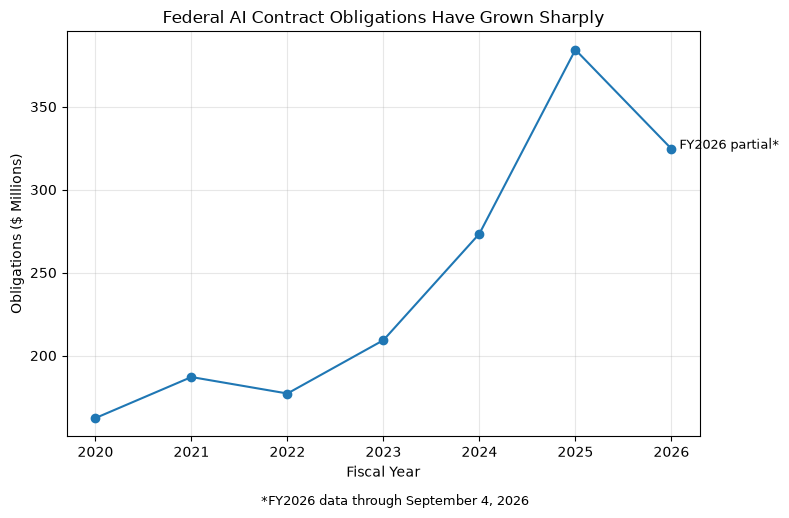

Chart 1 complete


In [20]:
chart1_data = spending_millions.loc[2020:2026]

plt.figure(figsize=(8, 5))

plt.plot(
    chart1_data.index,
    chart1_data.values,
    marker="o"
)

plt.title("Federal AI Contract Obligations Have Grown Sharply")
plt.xlabel("Fiscal Year")
plt.ylabel("Obligations ($ Millions)")

plt.grid(alpha=0.3)

plt.text(
    2026,
    chart1_data.loc[2026],
    "  FY2026 partial*",
    fontsize=9
)

plt.figtext(
    0.5,
    -0.02,
    "*FY2026 data through September 4, 2026",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.show()

print("Chart 1 complete")

### Finding 2: Defense Dominates AI Contracting

DoD accounts for 72.9% of identified AI contract obligations.

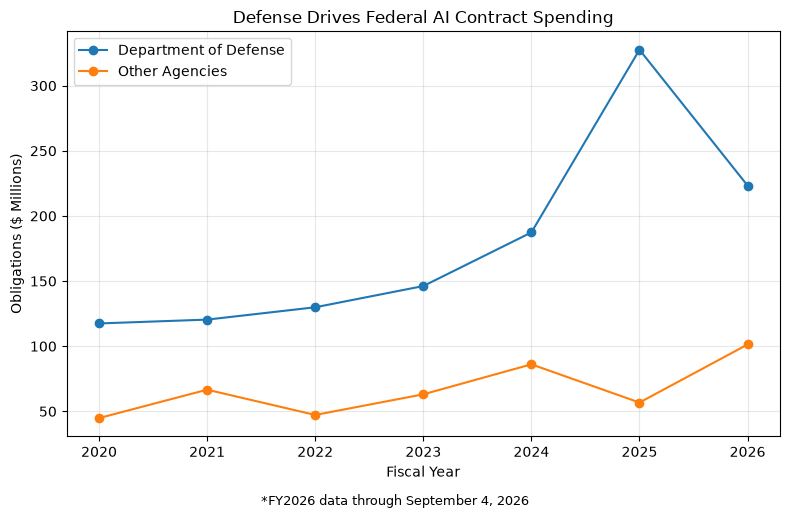

Chart 2 complete


In [21]:
chart2_data = dod_by_year / 1_000_000

plt.figure(figsize=(8, 5))

plt.plot(
    chart2_data.index,
    chart2_data["Department of Defense"],
    marker="o",
    label="Department of Defense"
)

plt.plot(
    chart2_data.index,
    chart2_data["Other Agencies"],
    marker="o",
    label="Other Agencies"
)

plt.title("Defense Drives Federal AI Contract Spending")
plt.xlabel("Fiscal Year")
plt.ylabel("Obligations ($ Millions)")

plt.legend()
plt.grid(alpha=0.3)

plt.figtext(
    0.5,
    -0.02,
    "*FY2026 data through September 4, 2026",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.show()

print("Chart 2 complete")

### Finding 3: Who Receives the Money?

A relatively small group of contractors receives a large share of AI contract obligations.

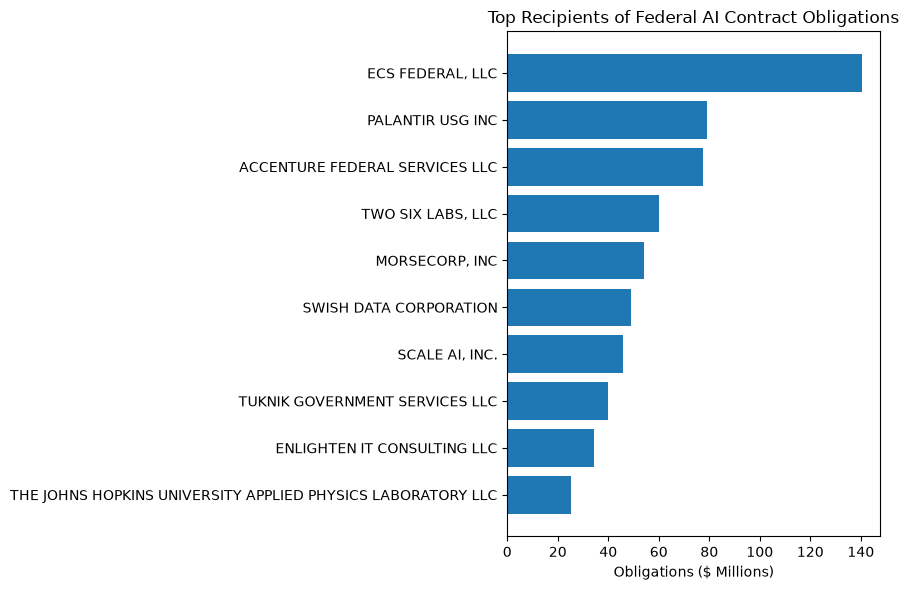

Chart 3 complete


In [22]:
chart3_data = (top_recipients / 1_000_000).sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    chart3_data.index,
    chart3_data.values
)

plt.title("Top Recipients of Federal AI Contract Obligations")
plt.xlabel("Obligations ($ Millions)")
plt.ylabel("")

plt.tight_layout()

plt.show()

print("Chart 3 complete")

In [23]:
service_spending = (
    ai_clean
    .groupby("product_or_service_code_description")["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 products and services by AI contract obligations:")
print((service_spending / 1_000_000).round(1))

Top 10 products and services by AI contract obligations:
product_or_service_code_description
NATIONAL DEFENSE R&D SERVICES; DEFENSE-RELATED ACTIVITIES; APPLIED RESEARCH                    181.9
NATIONAL DEFENSE R&D SERVICES; DEPARTMENT OF DEFENSE - MILITARY; APPLIED RESEARCH              167.3
SUPPORT- PROFESSIONAL: OTHER                                                                   146.2
IT AND TELECOM - BUSINESS APPLICATION/APPLICATION DEVELOPMENT SUPPORT SERVICES (LABOR)         130.3
NATIONAL DEFENSE R&D SERVICES; DEPARTMENT OF DEFENSE - MILITARY; EXPERIMENTAL DEVELOPMENT      100.2
NATIONAL DEFENSE R&D SERVICES; DEPARTMENT OF DEFENSE - MILITARY; BASIC RESEARCH                 90.2
R&D- GENERAL SCIENCE/TECHNOLOGY: ENGINEERING (APPLIED RESEARCH/EXPLORATORY DEVELOPMENT)         67.7
R&D- DEFENSE OTHER: OTHER (ADVANCED DEVELOPMENT)                                                63.5
R&D- DEFENSE OTHER: OTHER (ENGINEERING DEVELOPMENT)                                             61.

### Finding 4: AI Spending Is Tied to R&D

Many of the largest contract categories involve research and technology development.

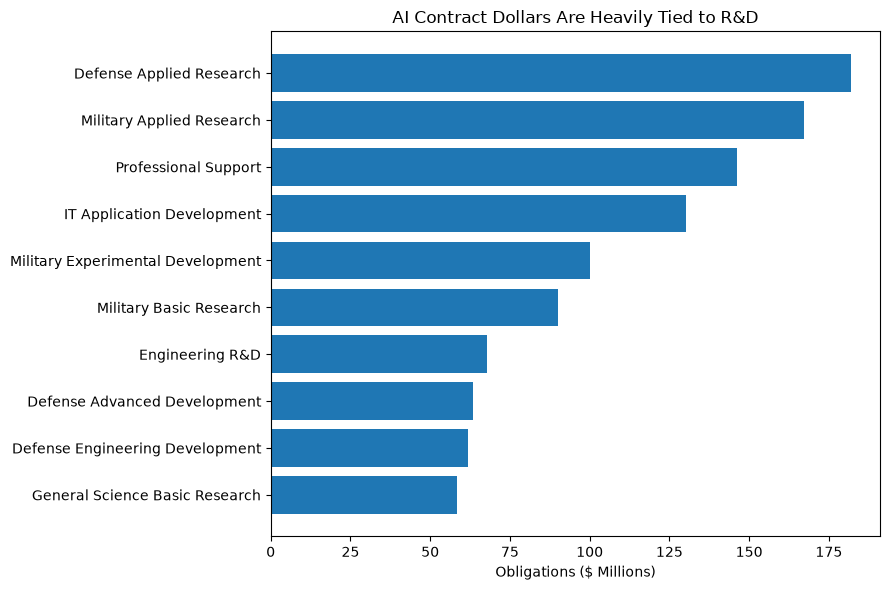

Chart 4 complete


In [24]:
chart4_data = service_spending.copy()

short_names = [
    "Defense Applied Research",
    "Military Applied Research",
    "Professional Support",
    "IT Application Development",
    "Military Experimental Development",
    "Military Basic Research",
    "Engineering R&D",
    "Defense Advanced Development",
    "Defense Engineering Development",
    "General Science Basic Research"
]

chart4_data.index = short_names

chart4_data = (chart4_data / 1_000_000).sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    chart4_data.index,
    chart4_data.values
)

plt.title("AI Contract Dollars Are Heavily Tied to R&D")
plt.xlabel("Obligations ($ Millions)")
plt.ylabel("")

plt.tight_layout()

plt.show()

print("Chart 4 complete")

## 6. Limitations and Ethical Considerations

This analysis captures contracts explicitly referencing artificial intelligence, not all federal AI spending. FY2026 is also incomplete.

In [25]:
ai_clean.to_csv(
    "../data/processed/ai_contracts_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully")
print("Rows saved:", len(ai_clean))

Cleaned dataset saved successfully
Rows saved: 2726


## 7. Conclusion

Federal AI contracting has grown substantially, with DoD driving much of the identified spending.